<a href="https://colab.research.google.com/github/expaetra/CM3070_final_project/blob/master/09_model_on_expanded_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
!git clone https://github.com/expaetra/CM3070_final_project.git
%cd CM3070_final_project

fatal: destination path 'CM3070_final_project' already exists and is not an empty directory.
/content/CM3070_final_project/CM3070_final_project


## Modeling on expanded data

After expandind the dataset, the same classifier is used to assess whether the increased data size leads to improved performance

Class imbalance will be assessed for the discipline category and addressed if needed by capping extreme outliers to produce a more balanced dataset.

In [19]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.feature_extraction.text import TfidfVectorizer

import nltk
from nltk.corpus import stopwords

In [20]:
# load dataset

df = pd.read_csv("backend/data/data_expansion.csv")
print(df.shape)
df.head()

(78411, 6)


,category,field,discipline,year,abstract,abstract_length
0,cs.LG,Machine Learning,Artificial Intelligence,2021,neural machine translation (nmt) systems aim t...,177
1,cs.LG,Machine Learning,Artificial Intelligence,2021,while neural networks have shown remarkable su...,203
2,cs.LG,Machine Learning,Artificial Intelligence,2021,"in recent times, a large number of people have...",187
3,cs.LG,Machine Learning,Artificial Intelligence,2021,emerging edge applications require both a fast...,194
4,cs.LG,Machine Learning,Artificial Intelligence,2021,comparison of data representations is a comple...,133


In [21]:
# show distribution

discipline_counts = df['discipline'].value_counts()
field_counts = df['field'].value_counts()
print("Discipline:\n", discipline_counts)
print("\nField:\n", field_counts)

Discipline:
 discipline
Artificial Intelligence         17314
Theory of Computation            7307
Multimedia                       4988
World Wide Web                   4727
Computer Hardware                2498
Computer Imaging and Vision      2495
Distributed Systems              2493
Information Retrieval            2492
Computational Science            2492
Robotics                         2492
Human-Computer Interaction       2491
Database Systems                 2487
Social Computing                 2486
Software Engineering             2484
Computer Networks                2481
Cybersecurity                    2480
Communication                    2465
Computer Programming             2456
Emerging Technologies            2456
Computer Graphics                2443
Theoretical Computer Science     2216
Computer Systems                 2168
Name: count, dtype: int64

Field:
 field
Hardware Architecture                   2498
Social Networks                         2496
Sound and

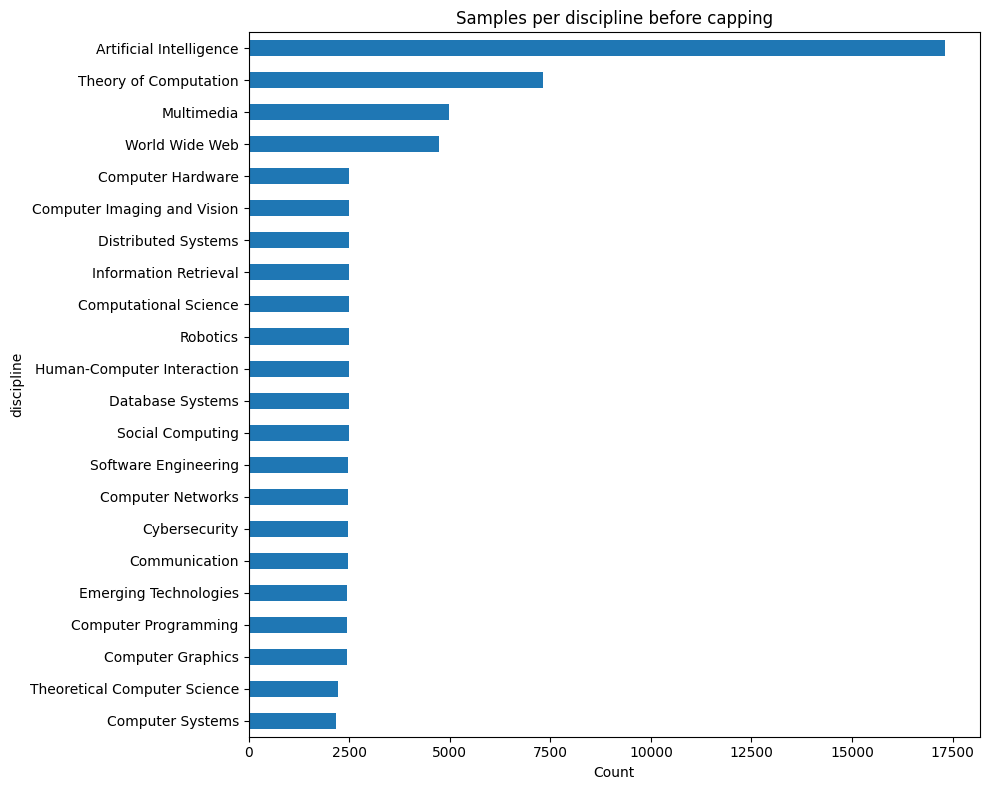

In [22]:
# visualization
plt.figure(figsize=(10, 8))
discipline_counts.sort_values().plot(kind='barh')
plt.title('Samples per discipline before capping')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

In [23]:
# apply cap

cap = 2500

df_capped = (
    df.groupby('discipline', group_keys=False)[df.columns]
      .apply(lambda x: x.sample(n=min(len(x), cap), random_state=42))
      .sample(frac=1, random_state=42)
      .reset_index(drop=True)
)

print(df_capped['discipline'].value_counts())

discipline
World Wide Web                  2500
Multimedia                      2500
Theory of Computation           2500
Artificial Intelligence         2500
Computer Hardware               2498
Computer Imaging and Vision     2495
Distributed Systems             2493
Robotics                        2492
Computational Science           2492
Information Retrieval           2492
Human-Computer Interaction      2491
Database Systems                2487
Social Computing                2486
Software Engineering            2484
Computer Networks               2481
Cybersecurity                   2480
Communication                   2465
Emerging Technologies           2456
Computer Programming            2456
Computer Graphics               2443
Theoretical Computer Science    2216
Computer Systems                2168
Name: count, dtype: int64


In [24]:
# stopwords

nltk.download("stopwords")

custom_stops = {
    'based', 'paper', 'show', 'results', 'problem', 'using', 'approach',
    'proposed', 'method', 'methods', 'propose', 'present', 'work',
    'used', 'use', 'two', 'one', 'new', 'also', 'shows', 'however',
    'provide', 'study', 'task', 'tasks', 'different', 'high', 'given'
}
stop_words = set(stopwords.words('english')).union(custom_stops)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [25]:
# prepare data

# discipline (capped)
X_text_disc = df_capped["abstract"].astype(str)
y_disc = df_capped["discipline"]

# field
X_text_field = df["abstract"].astype(str)
y_field = df["field"]

In [26]:
# train/test split

# discipline
X_train_text_disc, X_test_text_disc, y_disc_train, y_disc_test = train_test_split(
    X_text_disc,
    y_disc,
    test_size=0.2,
    random_state=42,
    stratify=y_disc
)

# field
X_train_text_field, X_test_text_field, y_field_train, y_field_test = train_test_split(
    X_text_field,
    y_field,
    test_size= 0.2,
    random_state=42,
    stratify=y_field
)

In [27]:
# TF-IDF (best representation from earlier experiments)

# TF-IDF (same setup for both)

vectorizer_disc = TfidfVectorizer(
    stop_words=list(stop_words),
    ngram_range=(1, 2),
    max_features=15000
)

vectorizer_field =TfidfVectorizer(
    stop_words=list(stop_words),
    ngram_range=(1,2),
    max_features=15000
)

# fit + transform
X_train_disc = vectorizer_disc.fit_transform(X_train_text_disc)
X_test_disc = vectorizer_disc.transform(X_test_text_disc)

X_train_field = vectorizer_field.fit_transform(X_train_text_field)
X_test_field =vectorizer_field.transform(X_test_text_field)

In [28]:
# train the logistic regression models

disc_model = LogisticRegression(
    max_iter=3000,
    random_state=42,
    class_weight='balanced',
    solver='liblinear'
)
disc_model.fit(X_train_disc, y_disc_train)

field_model = LogisticRegression(
    max_iter=3000,
    random_state=42,
    class_weight='balanced',
    solver='liblinear'
)
field_model.fit(X_train_field, y_field_train)

LogisticRegression(class_weight='balanced', max_iter=3000, random_state=42,
                   solver='liblinear')

In [29]:
y_disc_pred = disc_model.predict(X_test_disc)
y_field_pred = field_model.predict(X_test_field)

In [30]:
# predictions
y_disc_pred = disc_model.predict(X_test_disc)
y_field_pred = field_model.predict(X_test_field)

In [31]:
def evaluate_result(y_test, y_pred, task, model_name, representation):

    accuracy = accuracy_score(y_test, y_pred)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='macro', zero_division=0
    )
    weighted_p, weighted_r, weighted_f1, _ =precision_recall_fscore_support(
        y_test, y_pred, average='weighted', zero_division=0
    )

    return {
        "Task": task,
        "Model": model_name,
        "Representation": representation,
        "Accuracy": round(accuracy, 3),
        "Macro Precision": round(macro_p, 3),
        "Macro Recall": round(macro_r, 3),
        "Macro F1": round(macro_f1, 3),
        "Weighted Precision": round(weighted_p, 3),
        "Weighted Recall": round(weighted_r, 3),
        "Weighted F1": round(weighted_f1, 3)
    }

In [32]:
results = []

results.append(
    evaluate_result(
        y_disc_test,
        y_disc_pred,
        task="Discipline",
        model_name="Logistic Regression",
        representation="TF-IDF word n-grams (1-2) (capped discipline)"
    )
)
results.append(
    evaluate_result(
        y_field_test,
        y_field_pred,
        task="Field",
        model_name="Logistic Regression",
        representation="TF-IDF word n-grams (1-2) (uncapped field)"
    )
)

df_results = pd.DataFrame(results)
df_results

,Task,Model,Representation,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
0,Discipline,Logistic Regression,TF-IDF word n-grams (1-2) (capped discipline),0.624,0.622,0.623,0.621,0.622,0.624,0.621
1,Field,Logistic Regression,TF-IDF word n-grams (1-2) (uncapped field),0.541,0.529,0.542,0.533,0.528,0.541,0.532


In [33]:
# TF-IDF UNIGRAMS

vectorizer_uni_disc = TfidfVectorizer(
    stop_words=list(stop_words),
    ngram_range=(1, 1),
    max_features=15000
)

vectorizer_uni_field = TfidfVectorizer(
    stop_words=list(stop_words),
    ngram_range=(1, 1),
    max_features=15000
)

# transform
X_train_disc_uni = vectorizer_uni_disc.fit_transform(X_train_text_disc)
X_test_disc_uni = vectorizer_uni_disc.transform(X_test_text_disc)

X_train_field_uni = vectorizer_uni_field.fit_transform(X_train_text_field)
X_test_field_uni = vectorizer_uni_field.transform(X_test_text_field)

# train models
disc_model_uni = LogisticRegression(
    max_iter= 3000,
    random_state=42,
    class_weight='balanced',
    solver='liblinear'
)

field_model_uni = LogisticRegression(
    max_iter=3000,
    random_state=42,
    class_weight='balanced',
    solver='liblinear'
)

disc_model_uni.fit(X_train_disc_uni, y_disc_train)
field_model_uni.fit(X_train_field_uni, y_field_train)

# predictions
y_disc_pred_uni = disc_model_uni.predict(X_test_disc_uni)
y_field_pred_uni = field_model_uni.predict(X_test_field_uni)

In [34]:
results_uni = []

results_uni.append(
    evaluate_result(
        y_disc_test,
        y_disc_pred_uni,
        task="Discipline",
        model_name="Logistic Regression",
        representation="TF-IDF unigrams (capped discipline)"
    )
)
results_uni.append(
    evaluate_result(
        y_field_test,
        y_field_pred_uni,
        task="Field",
        model_name="Logistic Regression",
        representation="TF-IDF unigrams (uncapped field)"
    )
)

df_uni = pd.DataFrame(results_uni)
df_uni

,Task,Model,Representation,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
0,Discipline,Logistic Regression,TF-IDF unigrams (capped discipline),0.621,0.619,0.620,0.618,0.620,0.621,0.619
1,Field,Logistic Regression,TF-IDF unigrams (uncapped field),0.542,0.528,0.542,0.533,0.527,0.542,0.532


In [35]:
df_compare = pd.concat([df_uni, df_results], ignore_index=True)

df_compare.sort_values(by=["Task", "Accuracy"], ascending=False)

,Task,Model,Representation,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
1,Field,Logistic Regression,TF-IDF unigrams (uncapped field),0.542,0.528,0.542,0.533,0.527,0.542,0.532
3,Field,Logistic Regression,TF-IDF word n-grams (1-2) (uncapped field),0.541,0.529,0.542,0.533,0.528,0.541,0.532
2,Discipline,Logistic Regression,TF-IDF word n-grams (1-2) (capped discipline),0.624,0.622,0.623,0.621,0.622,0.624,0.621
0,Discipline,Logistic Regression,TF-IDF unigrams (capped discipline),0.621,0.619,0.620,0.618,0.620,0.621,0.619


In [36]:
# save

os.makedirs("/content/drive/MyDrive/CM3070_final_project/backend/data", exist_ok=True)
os.makedirs("/content/drive/MyDrive/CM3070_final_project/backend/data/results", exist_ok=True)

df_capped.to_csv(
    "/content/drive/MyDrive/CM3070_final_project/backend/data/expanded_modeling.csv",
    index=False
)

df_results.to_csv(
    "/content/drive/MyDrive/CM3070_final_project/backend/data/results/expanded_modeling_results.csv",
    index=False
)
print("Saved")

Saved
